# Principal Component Analysis (PCA)

In many real-world datasets, although each data point may have a large number of features, the data often lie close to a much lower-dimensional **hyperplane**. PCA is based on this assumption and tries to identify that lower-dimensional subspace.

PCA is mainly used for **dimensionality reduction**, **data compression**, and **feature extraction**. The basic idea is simple: instead of working in the original high-dimensional space, we find a few new directions that capture most of the information present in the data.

Mathematically, PCA is defined as the **orthogonal projection** of the data onto a lower-dimensional linear subspace such that the **variance of the projected data is maximized**. An equivalent statement is that PCA finds the subspace that **minimizes the mean squared reconstruction error**, i.e., the average squared distance between the original data points and their orthogonal projections onto the subspace.

This should not be confused with ordinary least squares regression. In least squares, we fit a line (or hyperplane) by minimizing the vertical residuals,

$$
\sum_{i=1}^{N}\left(y_i-\hat{y}_i\right)^2,
$$

where the distance is measured only along the (y)-direction. 

PCA, however, is fundamentally different. It does **not** minimize vertical distances. Instead, it minimizes the **perpendicular (orthogonal) distance** from each data point to the lower-dimensional subspace while simultaneously maximizing the variance of the projected data.

Our goal in PCA is therefore to:

* Find the direction(s) along which the data show the maximum variation.
* Project the data onto these directions to obtain a lower-dimensional representation.
* If required, reconstruct the original data using only the principal directions that capture most of the variance.

In the following sections, we will derive PCA from first principles by maximum variance formukation.




## Derivation of Principal Components

Suppose we are given a dataset $\{\mathbf{x}_i\}_{i=1}^{N}$, where each observation $\mathbf{x}_i \in \mathbb{R}^d$ is a $d$-dimensional feature vector.

Our goal is to project the data onto an $M$-dimensional subspace, where $M < d$, while preserving as much information as possible. In PCA, the information retained by the projection is measured by the **variance** of the projected data. Therefore, we seek the projection direction that maximizes this variance.

Let us first find a single direction $\mathbf{u}_1$. Since we are only interested in its direction and not its magnitude, we choose it to be a unit vector,

$$
\mathbf{u}_1^T \mathbf{u}_1 = 1.
$$

Projecting a data point $\mathbf{x}_i$ onto this direction gives a scalar

$$
z_i = \mathbf{u}_1^T \mathbf{x}_i.
$$

The mean of the projected data is

$$
\bar{z} = \mathbf{u}_1^T \bar{\mathbf{x}},
$$

where the sample mean of the original dataset is

$$
\bar{\mathbf{x}}
=
\frac{1}{N}
\sum_{i=1}^{N}
\mathbf{x}_i.
$$

The variance of the projected data is

$$
\frac{1}{N}
\sum_{i=1}^{N}
(z_i-\bar{z})^2
=
\mathbf{u}_1^T
\mathbf{S}
\mathbf{u}_1,
$$

where $\mathbf{S}$ is the covariance matrix,

$$
\mathbf{S}
=
\frac{1}{N}
\sum_{i=1}^{N}
(\mathbf{x}_i-\bar{\mathbf{x}})
(\mathbf{x}_i-\bar{\mathbf{x}})^T.
$$

Therefore, our objective is to maximize

$$
\mathbf{u}_1^T
\mathbf{S}
\mathbf{u}_1.
$$

This maximization must be performed under the constraint

$$
\mathbf{u}_1^T
\mathbf{u}_1
=
1,
$$

otherwise the magnitude of $\mathbf{u}_1$ could be increased indefinitely, making the objective function arbitrarily large. To impose this constraint, we introduce a Lagrange multiplier $\lambda_1$ and define the Lagrangian

$$
\mathcal{L}
=
\mathbf{u}_1^T
\mathbf{S}
\mathbf{u}_1
-
\lambda_1
\left(
\mathbf{u}_1^T
\mathbf{u}_1
-
1
\right).
$$

Setting the derivative of $\mathcal{L}$ with respect to $\mathbf{u}_1$ equal to zero gives

$$
\frac{\partial \mathcal{L}}{\partial \mathbf{u}_1}
=
0
\quad\Longrightarrow\quad
\mathbf{S}
\mathbf{u}_1
=
\lambda_1
\mathbf{u}_1.
$$

This is the eigenvalue equation of the covariance matrix. Therefore, the optimal projection direction must be an eigenvector of $\mathbf{S}$.

Multiplying both sides by $\mathbf{u}_1^T$ gives

$$
\mathbf{u}_1^T
\mathbf{S}
\mathbf{u}_1
=
\lambda_1
\mathbf{u}_1^T
\mathbf{u}_1.
$$

Using the normalization condition $\mathbf{u}_1^T\mathbf{u}_1=1$, we obtain

$$
\mathbf{u}_1^T
\mathbf{S}
\mathbf{u}_1
=
\lambda_1.
$$

Thus, the variance of the projected data is equal to the corresponding eigenvalue. Hence, the maximum variance is obtained by choosing the eigenvector corresponding to the **largest eigenvalue**. This eigenvector is called the **first principal component**.

The remaining principal components are obtained in the same way. Each new direction is chosen to maximize the projected variance while remaining orthogonal to all previously selected principal components. Consequently, the second principal component is the eigenvector corresponding to the second largest eigenvalue, the third principal component corresponds to the third largest eigenvalue, and so on. Together, these principal components form an orthonormal basis, ordered according to the amount of variance they explain.

In [5]:
import torch
from torchvision import datasets
from torchvision import transforms

import numpy as np
import matplotlib.pyplot as plt

In [6]:
transform = transforms.ToTensor()

In [7]:
# Load the MNIST data
train_dataset = datasets.MNIST(root="./data",train=True,download="True",transform=transform)
test_dataset = datasets.MNIST(root="./data",train=False,download="True",transform=transform)

In [8]:
print("Training images ",len(train_dataset))
print("Testing images ",len(train_dataset))

# Check one sample
image, label = train_dataset[0]
print(type(image))
print(image.shape) # 1, 28, 28
print(label) 

Training images  60000
Testing images  60000
<class 'torch.Tensor'>
torch.Size([1, 28, 28])
5


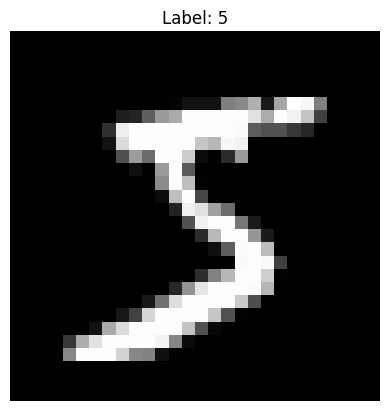

In [9]:
plt.imshow(image.squeeze(),cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

In [10]:
# Build data matrix
X_list = [] # Temporary python list to store flattened images
for image, label in train_dataset:
    X_list.append(image.view(-1)) # flatten each image
print(len(X_list))

X = torch.stack(X_list)
print(X.shape)

60000
torch.Size([60000, 784])


In [11]:
from sklearn.decomposition import PCA
latent_dim = 64
pca = PCA(n_components=latent_dim).fit(X)

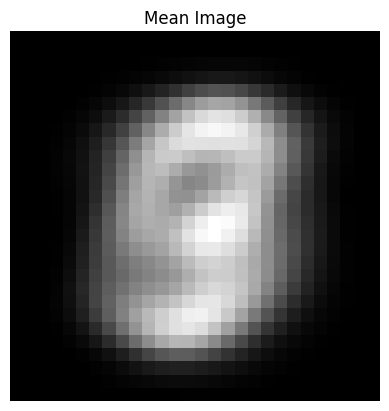

In [12]:
# Mean Image: average of all 60000 handwritten digits.
plt.imshow(pca.mean_.reshape(28,28), cmap="gray")
plt.title("Mean Image")
plt.axis("off")
plt.show()

In [13]:
# Each of the 64 principal components u_i is a vector in the original
# 784-dimensional pixel space. Together, they form a new orthogonal basis
# ordered by decreasing variance.
#
# Every image (a point in 784-dimensional space) is projected onto these
# 64 directions to obtain its coordinates (scores) in the PCA space.
#
# pca.components_ has shape (64, 784): each row is one principal direction.
print(pca.components_.shape)

# Since each principal component has 784 elements, it can be reshaped into
# a 28×28 image. These images are called "eigendigits". Although they do not
# correspond to actual handwritten digits, they capture the dominant patterns
# of variation in the dataset.

(64, 784)


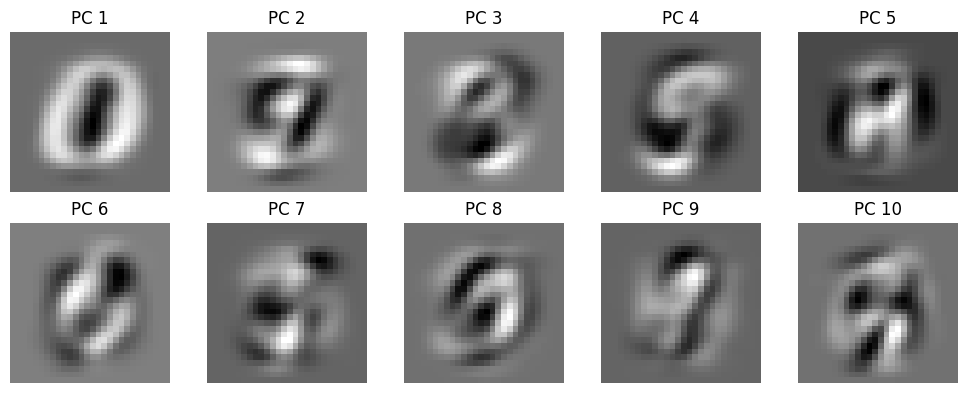

In [14]:
fig = plt.figure(figsize=(10,4))

for ij in range(10):
    axis = fig.add_subplot(2,5,ij+1)
    axis.imshow(pca.components_[ij].reshape(28,28),cmap="gray")
    axis.set_title(f"PC {ij+1}")
    axis.axis("off")

plt.tight_layout()
plt.show()


In [11]:
# pca.explained_variance_ratio_ holds the fraction of variance per component.
print(pca.explained_variance_ratio_) 

[0.09704664 0.07095924 0.06169089 0.05389419 0.04868797 0.04312231
 0.0327193  0.02883895 0.02762029 0.02357001 0.0210919  0.02022991
 0.01715818 0.01692111 0.01578641 0.01482953 0.01324561 0.01276897
 0.01187263 0.01152684 0.01066166 0.01006713 0.00953573 0.00912544
 0.00883405 0.00839319 0.00812579 0.00786366 0.00744733 0.00690859
 0.00658094 0.00648148 0.00602615 0.00586582 0.00570021 0.00543628
 0.00505786 0.00487859 0.00481429 0.00472266 0.00456747 0.00444836
 0.00418501 0.00398215 0.00384975 0.00375103 0.00362009 0.00351591
 0.00340058 0.00321874 0.00319017 0.00312805 0.00295983 0.00288955
 0.0028413  0.00271436 0.00269521 0.00258473 0.00253771 0.00244781
 0.00240506 0.00239263 0.00230408 0.00221532]


In [12]:
# Estimate the total variance
total_variance_explained = sum(pca.explained_variance_ratio_) 
print(f"top-{latent_dim} PCA components explain {total_variance_explained:.1%} of pixel variance")

top-64 PCA components explain 86.2% of pixel variance


In [13]:
# Project each image (a point in the original 784-dimensional pixel space)
# onto the 64 principal directions. The resulting coordinates are the PCA
# scores (also called latent coordinates or principal component scores).
# Thus, each image is now represented by just 64 numbers instead of 784 pixels.
Z = pca.transform(X)
print(Z[0])
print(Z.shape)   # (n_samples, 64)

[ 0.48601015  1.22617359  0.09613354  2.179443   -0.10704573  0.91167171
  0.91763035  0.62666469 -1.4255491   0.77814931 -0.77449815 -0.9962977
  0.44508395  2.93844101 -0.85984136  0.01840485 -1.29471367  1.21236821
  1.08860342  0.6522838  -0.10800727 -0.25236592  0.85167972 -0.98135071
 -0.18104337  0.39348802  1.20786968  0.66707892 -0.4922129  -0.48392039
 -0.38414881  0.135589   -0.4215072   0.33175869 -0.59765911 -0.78746233
 -0.2558463  -0.78517303 -0.61827668 -1.41075632  0.72779264 -0.60568668
  0.15781423  0.33319942  0.48576463 -0.02779618 -0.50016001  0.29975433
  0.13389515  0.07837729 -0.51075103 -0.42962894 -0.46421774 -0.34353411
  0.01216697 -0.64347832  0.46071033 -0.23833555 -0.5874324  -0.49339902
  0.26220609 -0.02070641  0.31903058 -0.32813004]
(60000, 64)


In [14]:
pca.components_.shape

(64, 784)

In [15]:
# Lets compute the projections z manually,
# Projection z : (N,64)
# X: (N,784)
# U: (64,784)
# z = (x-mu) . u.T # equivalent to pca.transform(X)
Zm = (X - pca.mean_) @ pca.components_.T
print(Zm[0])


tensor([ 0.4860,  1.2262,  0.0961,  2.1794, -0.1070,  0.9117,  0.9176,  0.6267,
        -1.4255,  0.7781, -0.7745, -0.9963,  0.4451,  2.9384, -0.8598,  0.0184,
        -1.2947,  1.2124,  1.0886,  0.6523, -0.1080, -0.2524,  0.8517, -0.9814,
        -0.1810,  0.3935,  1.2079,  0.6671, -0.4922, -0.4839, -0.3841,  0.1356,
        -0.4215,  0.3318, -0.5977, -0.7875, -0.2558, -0.7852, -0.6183, -1.4108,
         0.7278, -0.6057,  0.1578,  0.3332,  0.4858, -0.0278, -0.5002,  0.2998,
         0.1339,  0.0784, -0.5108, -0.4296, -0.4642, -0.3435,  0.0122, -0.6435,
         0.4607, -0.2383, -0.5874, -0.4934,  0.2622, -0.0207,  0.3190, -0.3281],
       dtype=torch.float64)


/tmp/ipykernel_9069/2278717564.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  Zm = (X - pca.mean_) @ pca.components_.T


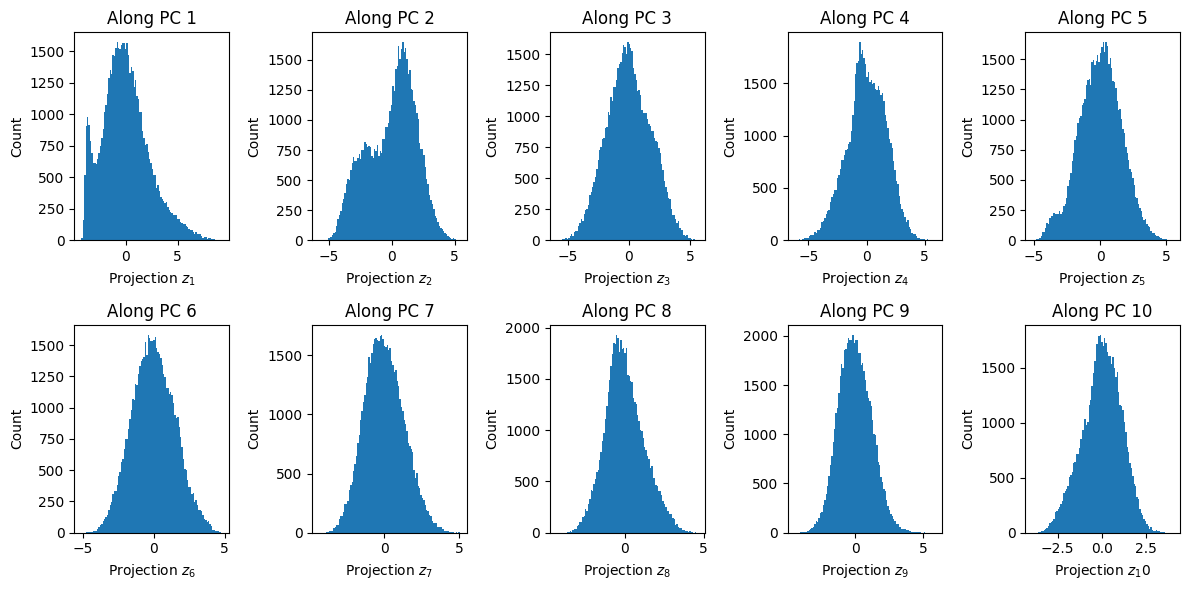

In [16]:
fig = plt.figure(figsize=(12, 6))

for i in range(10):
    ax = fig.add_subplot(2, 5, i + 1)
    ax.hist(Zm[:, i], bins=100)
    ax.set_title(f"Along PC {i+1}")
    ax.set_xlabel(f"Projection $z_{i+1}$")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

# Note that PC1 has the widest histogram (largest variance)
# PC2 is slightly narrower, and PC10 is narrower still.
# You will see that it naturally motivates us to model,
# the latent coordinates, z as gaussian random variables.

In [17]:
# Now let's estimate the variance of each principal component (latent coordinate).
# Since the projections are centered around zero, this should match the
# corresponding eigenvalues returned by PCA through 
# pca.explained_variance_

print(Z.shape)
N = Z.shape[0]

varZ = ((Z - Z.mean(axis=0))**2).sum(axis=0) / (N - 1)

print(varZ)
print(pca.explained_variance_) 
# Note: pca.explained_variance uses sample variance. (n-1)
print(np.allclose(varZ, pca.explained_variance_))

(60000, 64)
[5.11687307 3.74139088 3.25270849 2.84162073 2.56711776 2.27366341
 1.725155   1.52056025 1.45630527 1.2427501  1.11208952 1.06664055
 0.90468084 0.89218123 0.83235306 0.78190033 0.69838688 0.67325582
 0.62599524 0.60776303 0.56214589 0.53079883 0.50278026 0.48114704
 0.4657832  0.44253869 0.42843961 0.41461871 0.39266734 0.36426179
 0.34698596 0.34174189 0.31773429 0.30928082 0.30054904 0.28663271
 0.26668051 0.25722791 0.25383802 0.24900674 0.24082399 0.23454386
 0.22065865 0.20996268 0.20298138 0.19777669 0.19087248 0.18537972
 0.1792988  0.16971126 0.16820466 0.16492926 0.15605957 0.15235396
 0.14981035 0.14311701 0.14210765 0.13628201 0.13380287 0.129063
 0.12680906 0.12615355 0.12148498 0.11680484]
[5.11687307 3.74139088 3.25270849 2.84162073 2.56711776 2.27366341
 1.725155   1.52056025 1.45630527 1.2427501  1.11208952 1.06664055
 0.90468084 0.89218123 0.83235306 0.78190033 0.69838688 0.67325582
 0.62599524 0.60776303 0.56214589 0.53079883 0.50278026 0.48114704
 0.465

In [19]:
# Reconstruction

In [18]:
# An image is reconstructed by starting from the mean image and adding a
# weighted combination of these eigendigits, where the weights are the
# corresponding PCA scores z_i
# Reconstruct images from the latent representation

# Add mean image since it is subtracted initially
# x_hat = mu + z1*u1+z2*u2 + ... + z6*u6
# mu :(784,)
# Z: (N,64)
# U: (64,784)
xhat = pca.mean_ + Z @ pca.components_
print(xhat.shape)

(60000, 784)


In [25]:
# Instead of using all 64 principal components, we can reconstruct the
# image using only the first k components. Since the principal components
# are ordered by decreasing explained variance, the first few capture the
# most important structure while the later components capture finer details.

#pcs = [1, 2, 5, 10, 30, 64]
pcs = [1, 2, 3, 4, 5, 6]

xhat_k = {}

for k in pcs:
    xhat_k[k] = pca.mean_ + Z[:, k:] @ pca.components_[k:]

In [26]:
xhat_k[1]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(60000, 784))

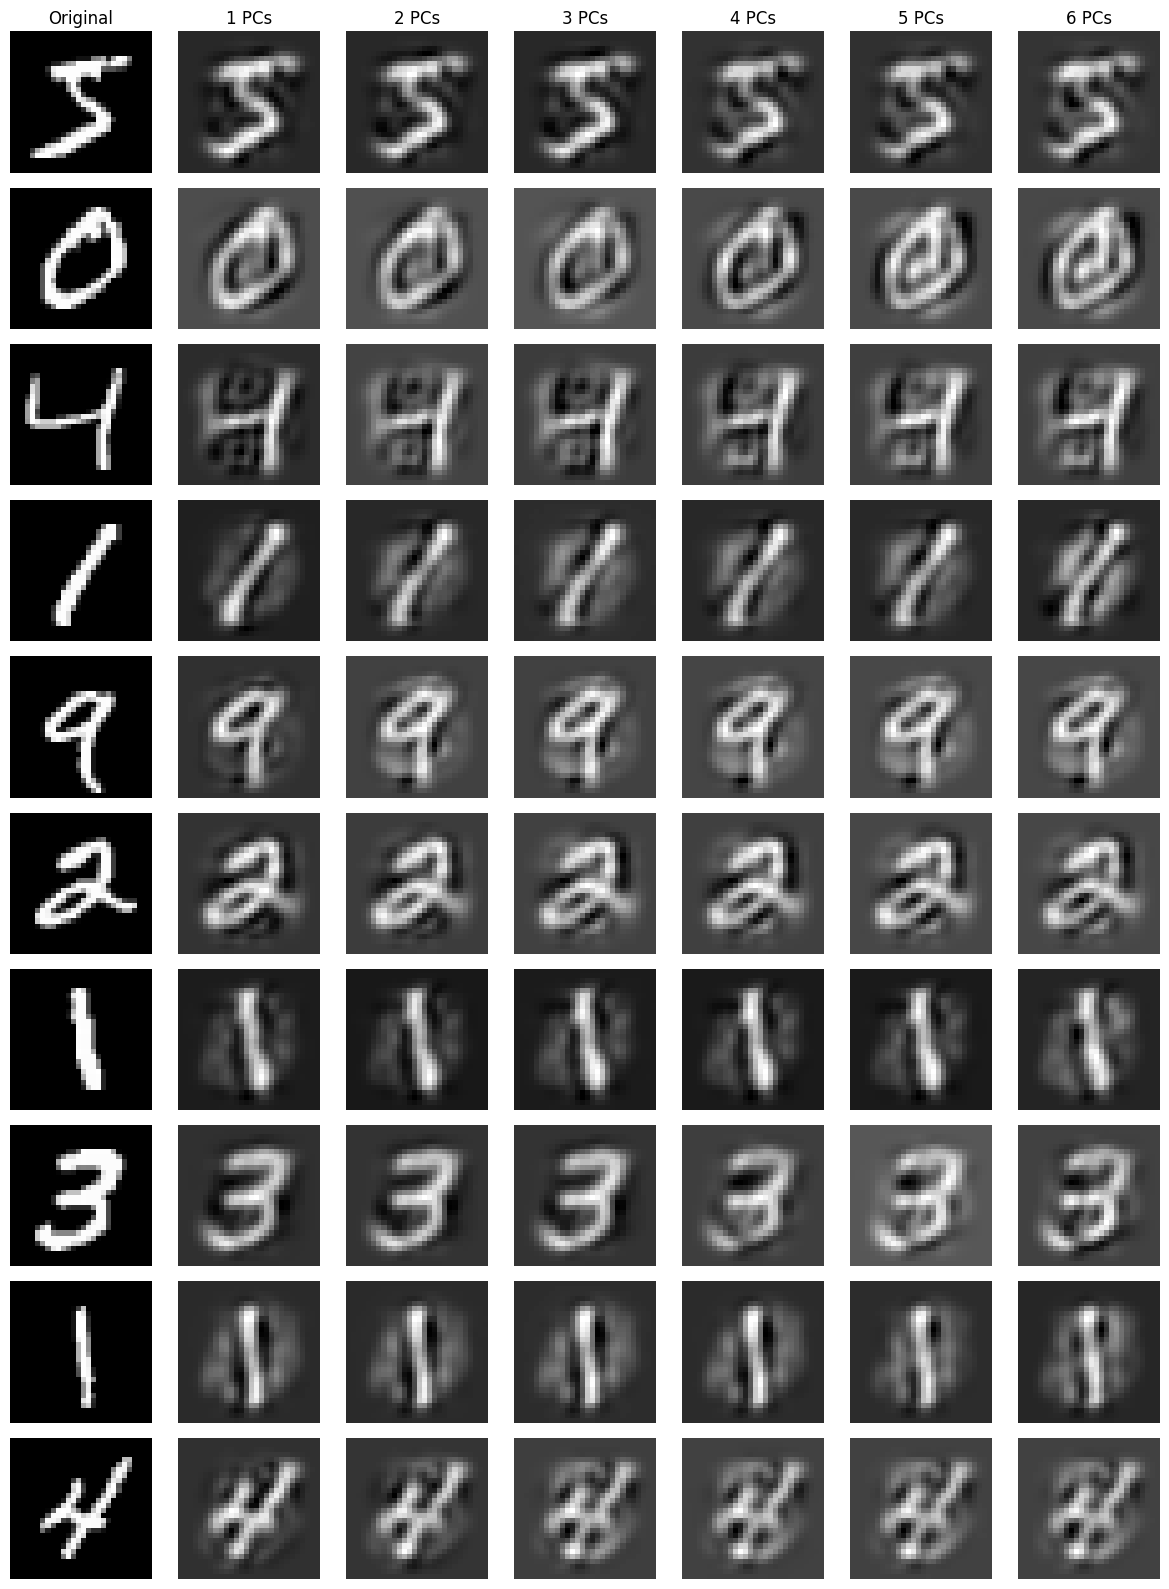

In [27]:
# Plot reconstructed images

fig = plt.figure(figsize=(12, 16))

for i in range(10):

    # Original image
    plt.subplot(10, 7, i*7 + 1)
    plt.imshow(X[i].reshape(28, 28), cmap="gray")
    if i == 0:
        plt.title("Original")
    plt.axis("off")

    # Reconstructions
    for j, k in enumerate(pcs):
        plt.subplot(10, 7, i*7 + j + 2)
        plt.imshow(xhat_k[k][i].reshape(28, 28), cmap="gray")
        if i == 0:
            plt.title(f"{k} PCs")
        plt.axis("off")

plt.tight_layout()
plt.show()

/tmp/ipykernel_15416/1453651364.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  residual = X - (pca.mean_ + Z[:, :64] @ pca.components_[:64])


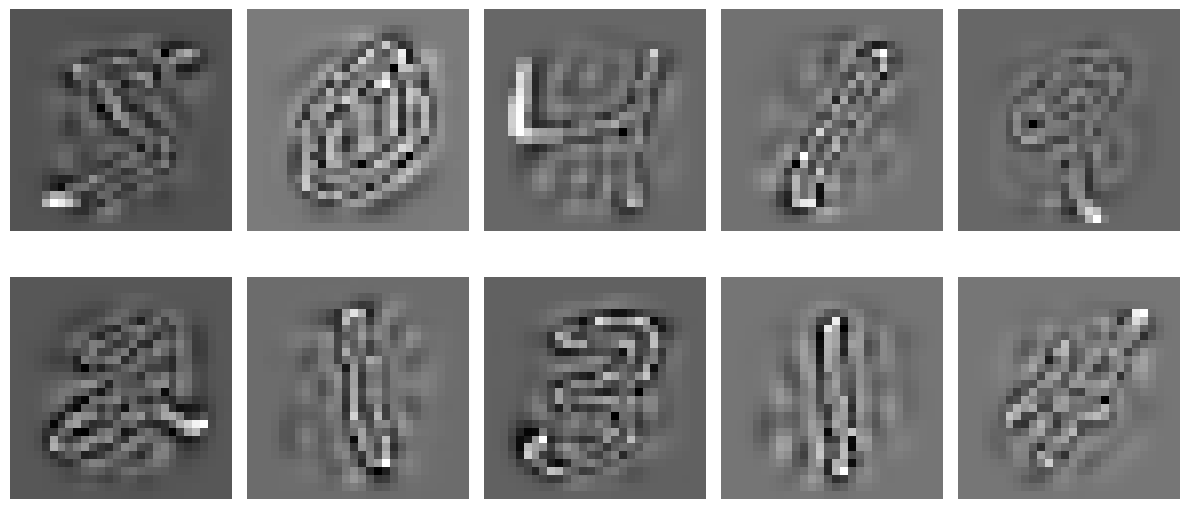

In [32]:
# DRaw Residual
residual = X - (pca.mean_ + Z[:, :64] @ pca.components_[:64])
fig = plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(residual[i].reshape(28, 28),cmap="gray",)
    plt.axis("off")
plt.tight_layout()
plt.show()